In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import datasets, model_selection, preprocessing, metrics, neighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [6]:
from pathlib import Path

data_path = Path("../Data/lab3.csv")
if not data_path.exists():
    data_path = Path("Data/lab3.csv")

df = pd.read_csv(data_path)

print("Pierwsze 5 wierszy:")
display(df.head(30))

print("\nInformacje o danych:")
print(df.info())

print("\nStatystyki opisowe:")
display(df.describe(include="all"))

#usunięcie duplikatów jeżelli istnieją
df = df.drop_duplicates().copy()
print(df.shape)

Pierwsze 5 wierszy:


,a,b,c,d,e,f,g,h,i,j,class
0,18.0625,6.65,4.82,5.010043,6.65,-0.70,0.263748,4.25,13.305,1.10,class1
1,12.2500,6.35,2.3O45,4.955367,6.35,-0.70,2.603217,3.50,12.795,1.10,class1
2,14.4400,6.05,4.340000000000001,5.009794,6.05,-0.70,-3.951455,3.80,12.285,0.95,class1
3,13.3225,5.90,4.22,4.998713,5.90,-0.70,-2.043009,3.65,12.030,1.25,class1
4,19.3600,6.50,4.7,5.046344,6.50,-0.70,-12.716327,4.40,13.050,1.10,class1
5,23.5225,7.10,5.1800000000000015,4.985358,7.10,-0.40,-25.968786,4.85,14.070,1.55,class1
6,16.8100,5.90,4.22,5.051891,5.90,-0.55,2.896809,4.10,12.030,1.10,class1
7,16.8100,6.50,4.7,5.071075,6.50,-0.70,-8.733046,4.10,13.050,1.25,class1
8,11.2225,5.60,3.9800000000000004,5.019748,5.60,-0.70,3.940727,3.35,11.520,1.10,class1
9,13.3225,6.35,4.580000000000001,5.006997,6.35,-0.85,9.351055,3.65,12.795,1.25,class1



Informacje o danych:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       150 non-null    float64
 1   b       150 non-null    float64
 2   c       150 non-null    str    
 3   d       150 non-null    float64
 4   e       150 non-null    float64
 5   f       150 non-null    float64
 6   g       150 non-null    float64
 7   h       150 non-null    float64
 8   i       150 non-null    float64
 9   j       150 non-null    float64
 10  class   150 non-null    str    
dtypes: float64(9), str(2)
memory usage: 13.0 KB
None

Statystyki opisowe:


,a,b,c,d,e,f,g,h,i,j,class
count,150.000000,150.000000,150,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,4.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class1
freq,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50
mean,13.284000,7.765000,NaN,5.008009,7.765000,0.799000,-0.790104,3.586000,15.200500,4.637000,NaN
std,4.862573,1.242099,NaN,0.048451,1.242099,1.143357,9.955411,0.653799,2.111569,2.647947,NaN
min,4.000000,5.450000,NaN,4.878648,5.450000,-0.850000,-25.968786,2.000000,11.265000,0.500000,NaN
25%,10.240000,6.650000,NaN,4.975031,6.650000,-0.550000,-6.490668,3.200000,13.305000,1.400000,NaN
50%,12.250000,7.700000,NaN,5.008976,7.700000,0.950000,-1.341948,3.500000,15.090000,5.525000,NaN
75%,15.602500,8.600000,NaN,5.043930,8.600000,1.700000,4.200927,3.950000,16.620000,6.650000,NaN


(150, 11)


In [7]:
print("\nLiczba braków danych:")
print(df.isnull().sum())
# --- KROK 1: Czyszczenie kolumny 'c' z niepotrzebnych liter ---
# Używamy .str.replace(), aby usunąć wszystko, co nie jest cyfrą (0-9) ani kropką (.).
df['c'] = df['c'].str.replace(r'[^0-9.]', '', regex=True)


# --- KROK 2: Konwersja oczyszczonej kolumny na typ liczbowy ---
# pd.to_numeric zamienia tekst na liczbę.
# errors='coerce' sprawi, że jeśli jakaś komórka będzie pusta po czyszczeniu,
# zostanie w niej wstawiona wartość NaN (brak danych), a program się nie zatrzyma.
df['c'] = pd.to_numeric(df['c'], errors='coerce')


# --- KROK 3: Sprawdzenie wyników ---
print("--- Informacje o danych PO CZYSZCZENIU ---")
df.info()

print("\n--- Sprawdzenie, czy powstały jakieś brakujące wartości ---")
# To polecenie pokaże, ile pustych komórek (NaN) jest w każdej kolumnie.
# Warto to sprawdzić, bo czyszczenie mogło usunąć całą zawartość komórki.
print(df.isnull().sum())



Liczba braków danych:
a        0
b        0
c        0
d        0
e        0
f        0
g        0
h        0
i        0
j        0
class    0
dtype: int64
--- Informacje o danych PO CZYSZCZENIU ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       150 non-null    float64
 1   b       150 non-null    float64
 2   c       150 non-null    float64
 3   d       150 non-null    float64
 4   e       150 non-null    float64
 5   f       150 non-null    float64
 6   g       150 non-null    float64
 7   h       150 non-null    float64
 8   i       150 non-null    float64
 9   j       150 non-null    float64
 10  class   150 non-null    str    
dtypes: float64(10), str(1)
memory usage: 13.0 KB

--- Sprawdzenie, czy powstały jakieś brakujące wartości ---
a        0
b        0
c        0
d        0
e        0
f        0
g        0
h        0
i        0
j        0
clas

In [8]:

df_n = df.drop(columns=['g', 'd'])

macierz_korelacji = df_n.corr(numeric_only=True)

# Wyświetlamy wynikową tabelę
print("Macierz korelacji:")
print(macierz_korelacji)

Macierz korelacji:
          a         b         c         e         f         h         i  \
a  1.000000 -0.134331 -0.124331 -0.134331 -0.389148  0.991980 -0.134331   
b -0.134331  1.000000  0.889736  1.000000  0.817941 -0.117570  1.000000   
c -0.124331  0.889736  1.000000  0.889736  0.739406 -0.111615  0.889736   
e -0.134331  1.000000  0.889736  1.000000  0.817941 -0.117570  1.000000   
f -0.389148  0.817941  0.739406  0.817941  1.000000 -0.366126  0.817941   
h  0.991980 -0.117570 -0.111615 -0.117570 -0.366126  1.000000 -0.117570   
i -0.134331  1.000000  0.889736  1.000000  0.817941 -0.117570  1.000000   
j -0.448208  0.871754  0.782225  0.871754  0.962865 -0.428440  0.871754   

          j  
a -0.448208  
b  0.871754  
c  0.782225  
e  0.871754  
f  0.962865  
h -0.428440  
i  0.871754  
j  1.000000  


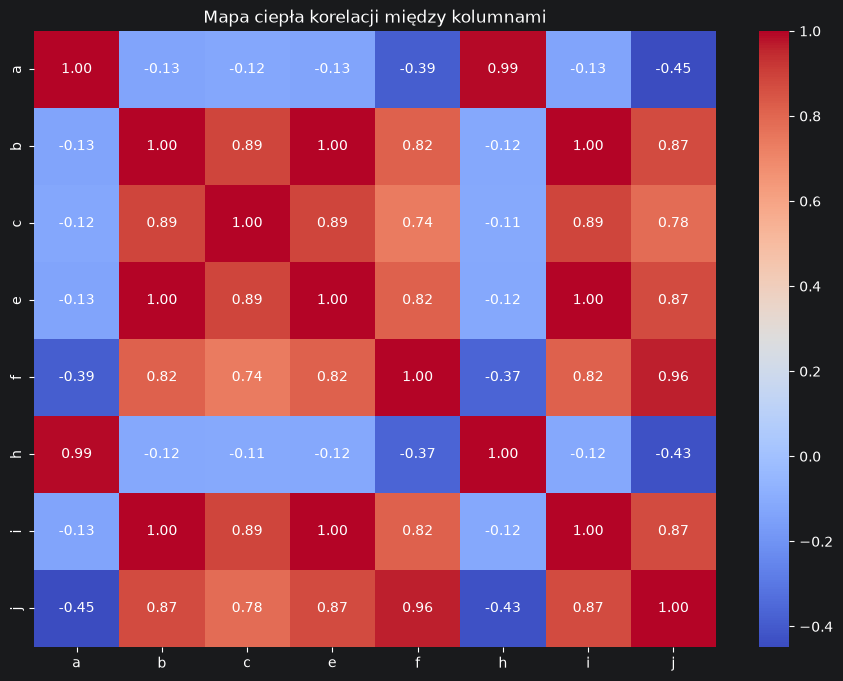

In [9]:
# Ustawiamy rozmiar wykresu, aby był bardziej czytelny
plt.figure(figsize=(11, 8))

# Tworzymy mapę ciepła
# annot=True - wyświetla wartości w komórkach
# cmap='coolwarm' - używa kolorów od niebieskiego (korelacja ujemna) do czerwonego (dodatnia)
sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm', fmt=".2f")

# Dodajemy tytuł
plt.title('Mapa ciepła korelacji między kolumnami')

# Wyświetlamy wykres
plt.show()

In [10]:
# Cechy (X) to wszystkie kolumny oprócz 'class'
X = df_n.drop('class', axis=1)

# Etykieta (y) to nasza kolumna docelowa 'class'
y = df_n['class']

accuracy_scores = []

for seed in range(1, 101):
    # Podział danych na zbiór treningowy i testowy z różnym random_state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    # Tworzymy obiekt skalera
    scaler = StandardScaler()

    # Uczymy skaler na danych treningowych i je transformujemy
    X_train_scaled = scaler.fit_transform(X_train)

    # Transformujemy dane testowe używając skalera nauczonego na zbiorze treningowym
    X_test_scaled = scaler.transform(X_test)

    # Tworzymy model KNN, ustawiając liczbę sąsiadów na 5
    knn = KNeighborsClassifier(n_neighbors=5)

    # Trenujemy model na przeskalowanych danych treningowych
    knn.fit(X_train_scaled, y_train)

    # Przewidujemy etykiety dla danych testowych
    y_pred = knn.predict(X_test_scaled)

    # --- Sprawdzamy wyniki ---

    # 1. Dokładność (Accuracy) - jaki procent predykcji był poprawny?
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)


# Obliczenie i wyświetlenie statystyk
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)
min_accuracy = np.min(accuracy_scores)
max_accuracy = np.max(accuracy_scores)
median_accuracy = np.median(accuracy_scores)

print("--- Statystyki dokładności modelu (ze 100 prób) ---")
print(f"Średnia dokładność: {mean_accuracy:.4f}")
print(f"Odchylenie standardowe: {std_accuracy:.4f}")
print(f"Minimalna dokładność: {min_accuracy:.4f}")
print(f"Maksymalna dokładność: {max_accuracy:.4f}")
print(f"Mediana dokładności: {median_accuracy:.4f}")


--- Statystyki dokładności modelu (ze 100 prób) ---
Średnia dokładność: 0.9202
Odchylenie standardowe: 0.0437
Minimalna dokładność: 0.7556
Maksymalna dokładność: 1.0000
Mediana dokładności: 0.9333


In [11]:
df_n.shape

(150, 9)

Wykryte nazwy klas: ['class1' 'class2' 'class3']


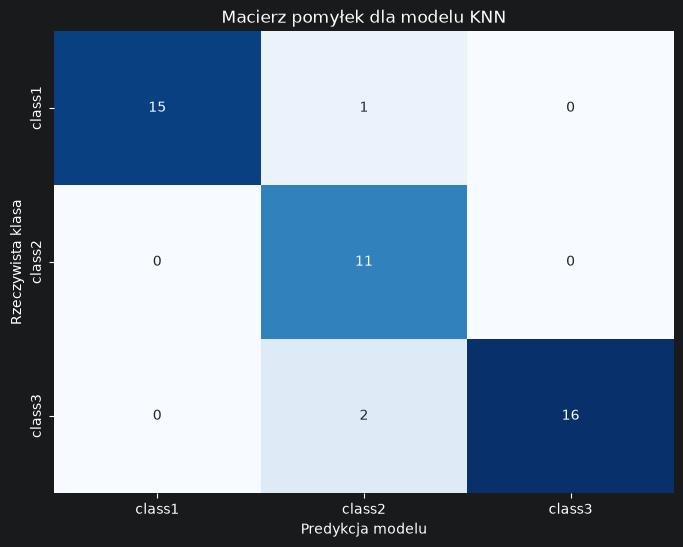


Raport klasyfikacji:
              precision    recall  f1-score   support

      class1       1.00      0.94      0.97        16
      class2       0.79      1.00      0.88        11
      class3       1.00      0.89      0.94        18

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.95      0.93      0.94        45



In [12]:
class_names = knn.classes_
print(f"Wykryte nazwy klas: {class_names}")

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Obliczamy macierz pomyłek
cm = confusion_matrix(y_test, y_pred)

# Tworzymy wizualizację macierzy pomyłek
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predykcja modelu")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek dla modelu KNN")
plt.show()

# Wyświetlamy szczegółowy raport klasyfikacji
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=class_names))

#Informacje wstępne
Gdy wyświetliliśmy pierwsze wiersze danych i informacje, zauważyliśmy, że kolumna 'c' miała typ object, mimo że zawierała w większości liczby dziesiętne. W wierszu z indeksem 1 w danych widniała wartość 2.3O45. Obecność litery 'O' w wartościach numerycznych uniemożliwia traktowanie tej kolumny jako liczbowej Usunięcie niechcianych znaków i przekształcenie kolumny na typ liczbowy jest niezbędne aby algorytm uczenia maszynowego działał porawnie. Usunięcie kolumn d i g zostało wykonane po analizie korelacji między cechami. Usuwanie cech o niskiej korelacji pomaga skoncentrować model na najważniejszych informacjach, redukując ryzyko przetrenowania i poprawiając interpretowalność

#Wnioski
Średnia dokładność oraz mediana świadczą o tym, że model KNN jest bardzo dobrze dopasowany do analizowanego zbioru danych. Niskie odchylenie standardowe  jest kluczową informacją. Oznacza to, że wyniki dokładności uzyskane w 100 próbach były do siebie bardzo zbliżone. Model nie jest wrażliwy na konkretny sposób podziału danych na zbiór treningowy i testowy. Daje to dużą pewność, że jego wysoka skuteczność nie jest przypadkowa, a sam model będzie działał podobnie dobrze na nowych, niewidzianych wcześniej danych. Rozpiętość wyników między minimalną dokładnością a maksymalną pokazuje, że chociaż model jest generalnie stabilny, mogą zdarzyć się gorsze i lepsze podziały danych.